Ten notebook jest przeznaczony do badania algorytmów na zbiorach tekstowych **BBC News**

# BBC News Embeddings

Ten zbiór danych składa się z 2225 dokumentów ze strony BBC news odnoszących się do 5 obszrów tematycznych z lat 2004-2005


1.  **Wektoryzacja tesktów** tworzymy reprezentacje wektorowe na dwa sposoby, źeby pokazać,
 źe na późniejszą redukcję wymiarów duźy wpływ ma tekźe awybór algorytmu, który tworzt wektory

- paragraph-embedddingi MiniLM https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

- TF-IDF

2.

In [24]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from utils.scores import Dataset, DatasetEvaluator
from sklearn.preprocessing import StandardScaler
from utils.plots import plot_2d_projection, plot_3d_interactive
import matplotlib.pyplot as plt
import numpy as np

## Załadowanie danych

In [2]:
bbc_data = pd.read_csv('data/bbc-news-data.csv', sep='\t')
bbc_data.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [3]:

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10574.82it/s]


In [4]:
embeddings = []
for category, content in bbc_data[['category', 'content']].values:
    embedding = model.encode(content)
    embeddings.append(embedding)


bbc_data['embedding'] = embeddings
bbc_data.head()


,category,filename,title,content,embedding
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"[-0.050983198, -0.070668444, 0.013510504, -0.0..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"[0.006186242, -0.047031574, -0.017026851, 0.00..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"[-0.07426079, 0.024880314, -0.014749284, 0.001..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"[0.040098134, -0.023337724, -0.010271507, 0.03..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"[0.026878353, -0.05364739, -0.007522971, -0.07..."


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(bbc_data['content'])

bbc_data['tdidf_embedding'] = list(tfidf_matrix.toarray())
bbc_data.head()

,category,filename,title,content,embedding,tdidf_embedding
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"[-0.050983198, -0.070668444, 0.013510504, -0.0...","[0.0, 0.021263676803950603, 0.0, 0.0, 0.0, 0.0..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"[0.006186242, -0.047031574, -0.017026851, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"[-0.07426079, 0.024880314, -0.014749284, 0.001...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"[0.040098134, -0.023337724, -0.010271507, 0.03...","[0.0, 0.019997434150077344, 0.0, 0.0, 0.0, 0.0..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"[0.026878353, -0.05364739, -0.007522971, -0.07...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [6]:
all_minilm_embeddings = bbc_data['embedding'].tolist()
tfidf_embeddings = bbc_data['tdidf_embedding'].tolist()

In [7]:
def map_category_to_color(category_vector):
    color_map = {
        'business': 'red',
        'entertainment': 'blue',
        'politics': 'green',
        'sport': 'orange',
        'tech': 'purple'
    }
    return [ color_map.get(category, 'black') for category in category_vector ]

In [8]:
categories = bbc_data['category'].unique()

In [9]:
evaluator_embeddings =DatasetEvaluator(Dataset(bbc_data['embedding'].tolist(), bbc_data['category'].tolist()))
evaluator_embeddings.scale(StandardScaler())
evaluator_tfidf = DatasetEvaluator(Dataset(bbc_data['tdidf_embedding'].tolist(), bbc_data['category'].tolist()))
evaluator_tfidf.scale(StandardScaler())

Scaling with StandardScaler...
Scaling with StandardScaler...


# LDA

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_embeddings = LinearDiscriminantAnalysis(n_components=2).fit_transform(evaluator_embeddings.X_train, evaluator_embeddings.y_train)
lda_tfidf = LinearDiscriminantAnalysis(n_components=2).fit_transform(evaluator_tfidf.X_train, evaluator_tfidf.y_train)
reductions = {
    'LDA on MiniLM2d': lda_embeddings,
    'LDA on TF-IDF2d': lda_tfidf
}



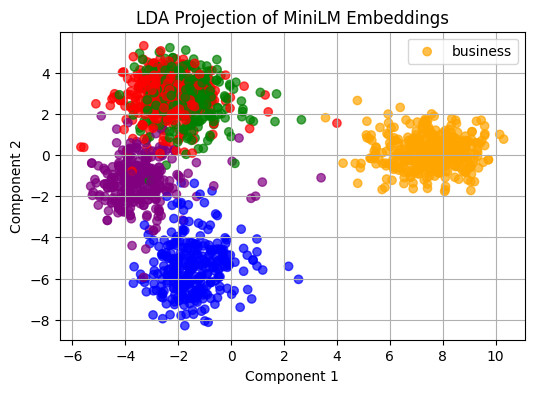

In [ ]:
plot_2d_projection(reductions['LDA on MiniLM2d'], map_category_to_color(evaluator_embeddings.y_train), title='LDA Projection of MiniLM Embeddings',show_colorbar=False)
plt.legend(categories)


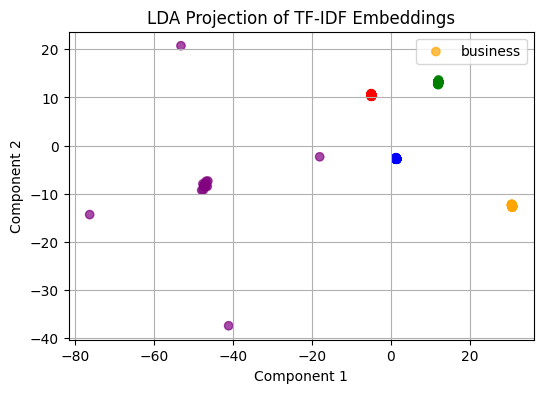

In [ ]:
plot_2d_projection(reductions['LDA on TF-IDF2d'], map_category_to_color(evaluator_embeddings.y_train), title='LDA Projection of TF-IDF Embeddings',show_colorbar=False)
plt.legend(categories)

In [25]:
lda_embeddings_3d = LinearDiscriminantAnalysis(n_components=3).fit_transform(evaluator_embeddings.X_train, evaluator_embeddings.y_train)
plot_3d_interactive(lda_embeddings_3d, np.array(evaluator_embeddings.y_train), title='3D LDA Projection of MiniLM Embeddings')
lda_tfidf_3d = LinearDiscriminantAnalysis(n_components=3).fit_transform(evaluator_tfidf.X_train, evaluator_tfidf.y_train)
plot_3d_interactive(lda_tfidf_3d, np.array(evaluator_tfidf.y_train), title='3D LDA Projection of TF-IDF Embeddings')

# PCA


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/utils/plots.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/matplotlib/collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/utils/plots.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/matplotlib/collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make 

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'PCA Projection of TF-IDF Embeddings'}, xlabel='Component 1', ylabel='Component 2'>)

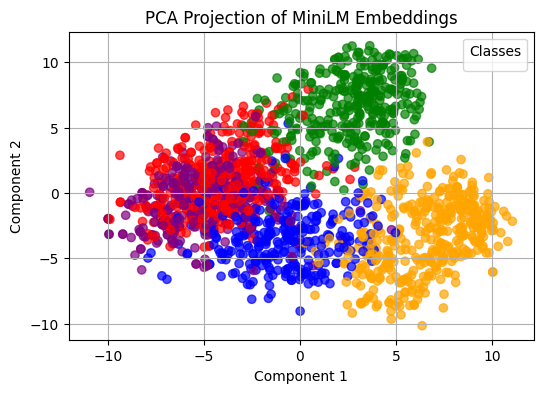

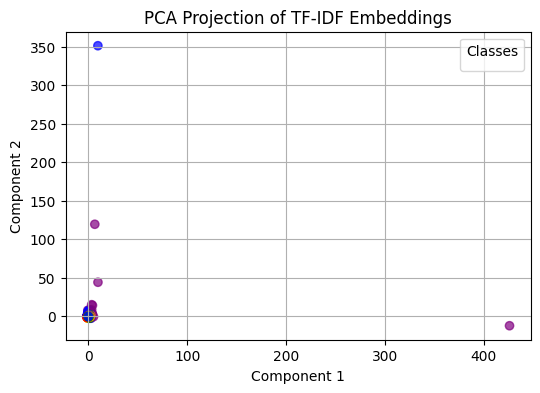

In [26]:
from sklearn.decomposition import PCA
pca_2d_embeddings = PCA(n_components=2).fit_transform(evaluator_embeddings.X_train)
plot_2d_projection(pca_2d_embeddings, map_category_to_color(evaluator_embeddings.y_train), title='PCA Projection of MiniLM Embeddings',show_colorbar=False)
pca_2d_tfidf = PCA(n_components=2).fit_transform(evaluator_tfidf.X_train)
plot_2d_projection(pca_2d_tfidf, map_category_to_color(evaluator_tfidf.y_train), title='PCA Projection of TF-IDF Embeddings',show_colorbar=False)


In [27]:
pca_3d_embeddings = PCA(n_components=3).fit_transform(evaluator_embeddings.X_train)
plot_3d_interactive(pca_3d_embeddings, np.array(evaluator_embeddings.y_train), title='3D PCA Projection of MiniLM Embeddings')
pca_3d_tfidf = PCA(n_components=3).fit_transform(evaluator_tfidf.X_train)
plot_3d_interactive(pca_3d_tfidf, np.array(evaluator_tfidf.y_train), title='3D PCA Projection of TF-IDF Embeddings')

## Kernel PCA

/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/utils/plots.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/matplotlib/collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/utils/plots.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/matplotlib/collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make 

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Kernel PCA Projection of TF-IDF Embeddings'}, xlabel='Component 1', ylabel='Component 2'>)

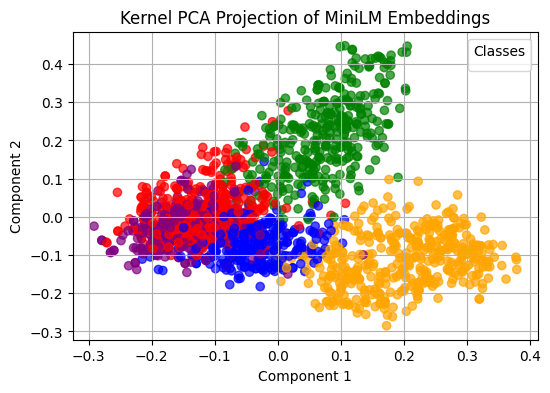

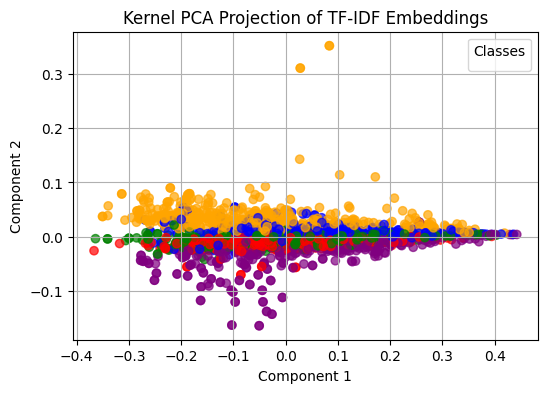

In [28]:
from sklearn.decomposition import KernelPCA
kpca_2d_embeddings = KernelPCA(n_components=2, kernel='rbf').fit_transform(evaluator_embeddings.X_train)
plot_2d_projection(kpca_2d_embeddings, map_category_to_color(evaluator_embeddings.y_train), title='Kernel PCA Projection of MiniLM Embeddings',show_colorbar=False)
kpca_2d_tfidf = KernelPCA(n_components=2, kernel='rbf').fit_transform(evaluator_tfidf.X_train)
plot_2d_projection(kpca_2d_tfidf, map_category_to_color(evaluator_tfidf.y_train), title='Kernel PCA Projection of TF-IDF Embeddings',show_colorbar=False)

In [29]:
kernel_pca_3d_embeddings = KernelPCA(n_components=3, kernel='rbf').fit_transform(evaluator_embeddings.X_train)
plot_3d_interactive(kernel_pca_3d_embeddings, np.array(evaluator_embeddings.y_train), title='3D Kernel PCA Projection of MiniLM Embeddings')
kernel_pca_3d_tfidf = KernelPCA(n_components=3, kernel='rbf').fit_transform(evaluator_tfidf.X_train)
plot_3d_interactive(kernel_pca_3d_tfidf, np.array(evaluator_tfidf.y_train), title='3D Kernel PCA Projection of TF-IDF Embeddings')

In [32]:
kernel_pca_linear_3d_tfidf = KernelPCA(n_components=3, kernel='linear').fit_transform(evaluator_tfidf.X_train)
plot_3d_interactive(kernel_pca_linear_3d_tfidf, np.array(evaluator_tfidf.y_train), title='3D Linear Kernel PCA Projection of TF-IDF Embeddings')

# Uźyteczność do outlier detection

Zbadamy na sztucznym zbiorze danych:
generujemy dane gdzie 2 wymiary są uźyteczne 
a reszta to szum 

In [149]:
def make_synthetic_outlier_data(

    n_normal=1000,
    n_outliers=50,
    n_noise_dims=98,
    noise_scale=3.0,
    random_state=42
):

    rng = np.random.default_rng(random_state)
    X_normal_signal = rng.normal(

        loc=0.0,
        scale=1.0,
        size=(n_normal, 2)
    )

    X_outlier_signal = rng.normal(
        loc=10.0,
        scale=0.8,
        size=(n_outliers, 2)

    )


    X_normal_noise = rng.normal(
        loc=0.0,
        scale=noise_scale,
        size=(n_normal, n_noise_dims)

    )

    X_outlier_noise = rng.normal(
        loc=0.0,
        scale=noise_scale,
        size=(n_outliers, n_noise_dims)

    )

    X_normal = np.hstack([X_normal_signal, X_normal_noise])
    X_outlier = np.hstack([X_outlier_signal, X_outlier_noise])
    X = np.vstack([X_normal, X_outlier])
    # 0 = normalny, 1 = outlier
    y = np.array([0] * n_normal + [1] * n_outliers)
    return X, y

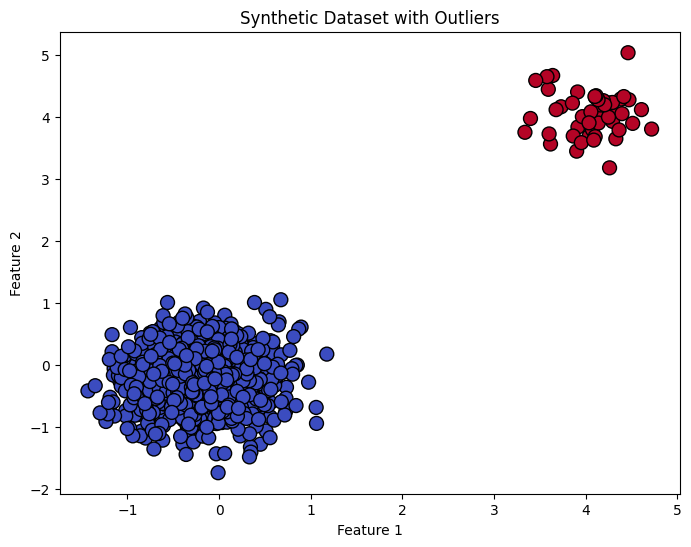

In [151]:
X, y = make_synthetic_outlier_data()
scaler = StandardScaler()
X = scaler.fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Synthetic Dataset with Outliers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

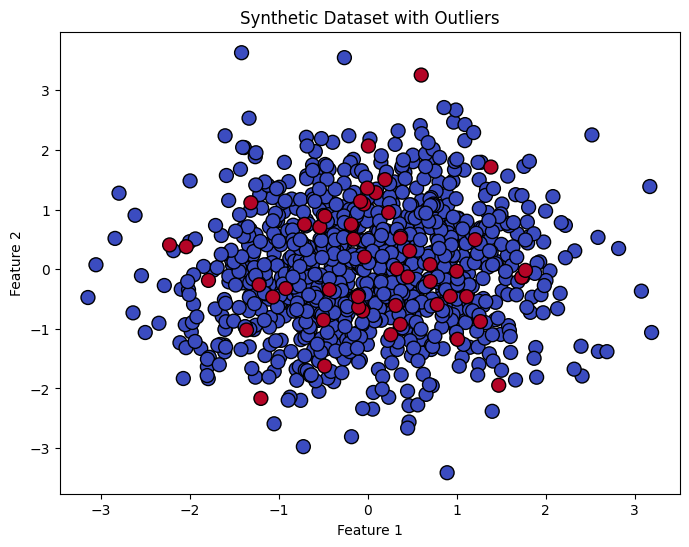

In [152]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 4], X[:, 5], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Synthetic Dataset with Outliers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1000
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00         0

    accuracy                           0.91      1050
   macro avg       0.32      0.32      0.32      1050
weighted avg       0.91      0.91      0.91      1050



/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use 

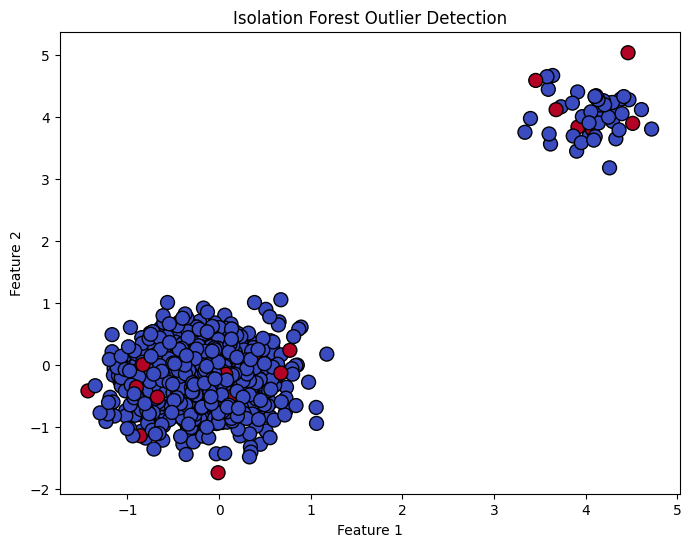

In [194]:
y_pred = IsolationForest(random_state=42, contamination=0.05).fit(X).predict(X)
from sklearn.metrics import classification_report
print(classification_report(y, 1-y_pred))
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=1-y_pred, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Isolation Forest Outlier Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


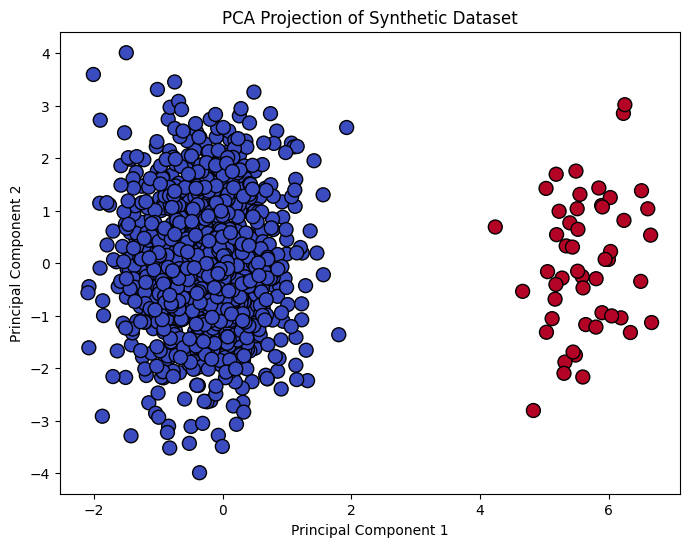

In [195]:
pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(pca[:, 0], pca[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.title('PCA Projection of Synthetic Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()  


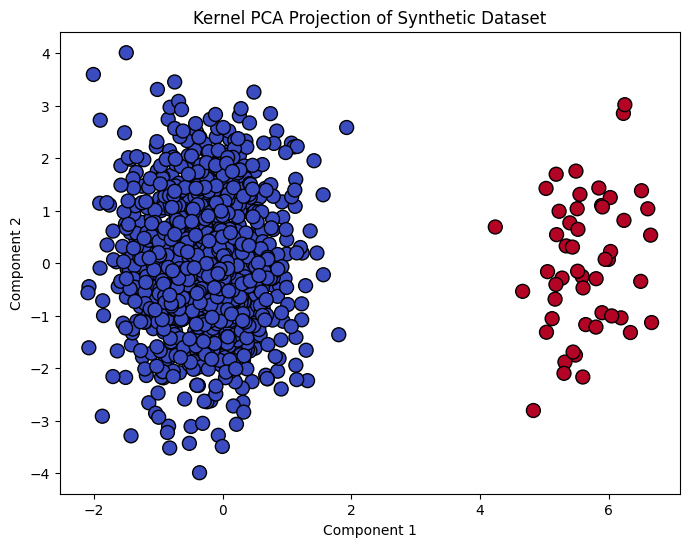

In [196]:
kernel_pca = KernelPCA(n_components=2, kernel='linear').fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(kernel_pca[:, 0], kernel_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Kernel PCA Projection of Synthetic Dataset')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00         0

    accuracy                           0.94      1050
   macro avg       0.33      0.33      0.33      1050
weighted avg       0.94      0.94      0.94      1050



/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use 

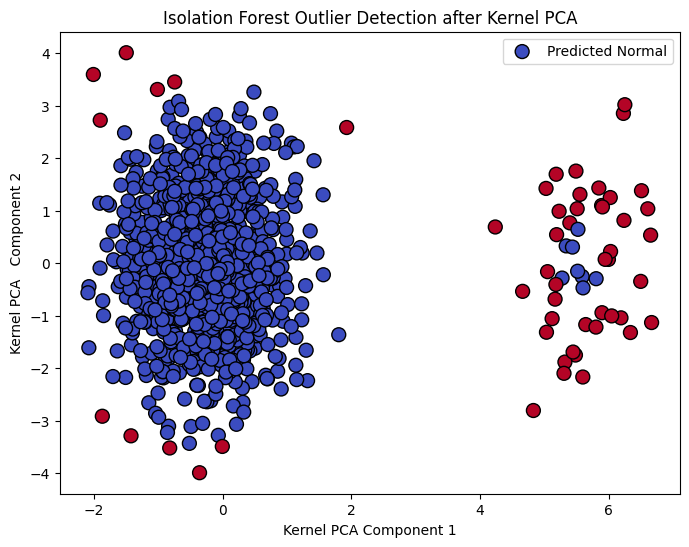

In [197]:
from sklearn.ensemble import IsolationForest
y_pred = IsolationForest(random_state=42, contamination=0.05).fit(kernel_pca).predict(kernel_pca)
print(classification_report(y, 1-y_pred))
plt.figure(figsize=(8, 6))
plt.scatter(kernel_pca[:, 0], kernel_pca[:, 1], c=1-y_pred, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Isolation Forest Outlier Detection after Kernel PCA')
plt.xlabel('Kernel PCA Component 1')
plt.ylabel('Kernel PCA   Component 2')
plt.legend(['Predicted Normal', 'Predicted Outlier'])
plt.show()

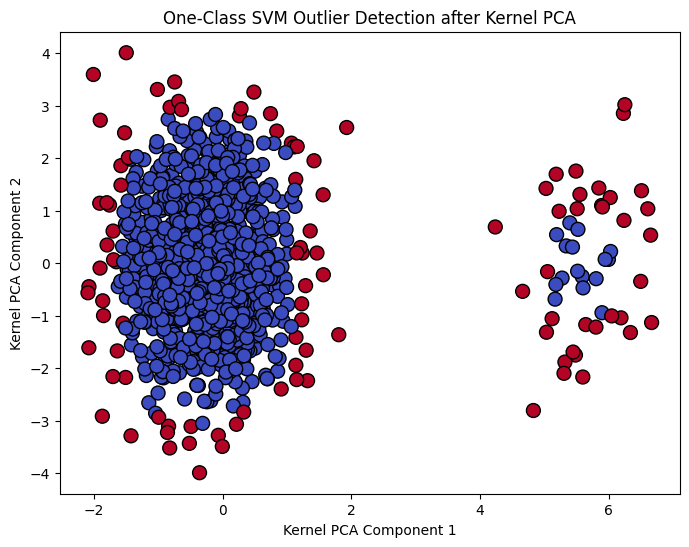

In [198]:
y_pred_after_reduction = OneClassSVM(nu=0.1, kernel='rbf').fit(kernel_pca).predict(kernel_pca)

plt.figure(figsize=(8, 6))
plt.scatter(kernel_pca[:, 0], kernel_pca[:, 1], c=1-y_pred_after_reduction, cmap='coolwarm', edgecolor='k', s=100)
plt.title('One-Class SVM Outlier Detection after Kernel PCA')
plt.xlabel('Kernel PCA Component 1')
plt.ylabel('Kernel PCA Component 2')
plt.show()


In [199]:
print(classification_report(y, y_pred_after_reduction))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       0.00      0.00      0.00      1000
           1       0.02      0.32      0.03        50

    accuracy                           0.02      1050
   macro avg       0.01      0.11      0.01      1050
weighted avg       0.00      0.02      0.00      1050



/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use 

/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


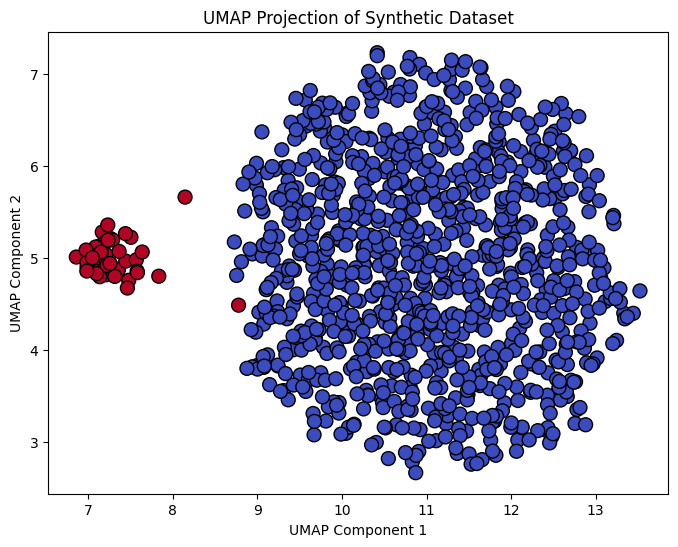

In [200]:
from umap import UMAP
umap_projection = UMAP(n_components=2, random_state=42).fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(umap_projection[:, 0], umap_projection[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.title('UMAP Projection of Synthetic Dataset')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

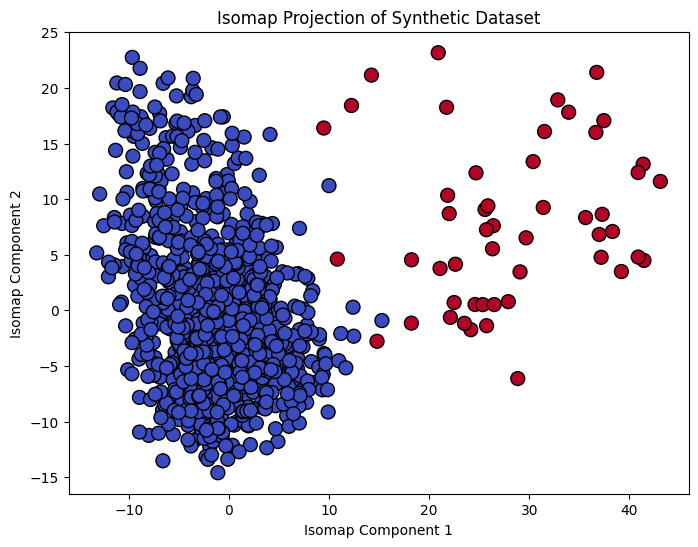

In [201]:
from sklearn.manifold import Isomap
isomap_projection = Isomap(n_components=2).fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(isomap_projection[:, 0], isomap_projection[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Isomap Projection of Synthetic Dataset')
plt.xlabel('Isomap Component 1')
plt.ylabel('Isomap Component 2')
plt.show()

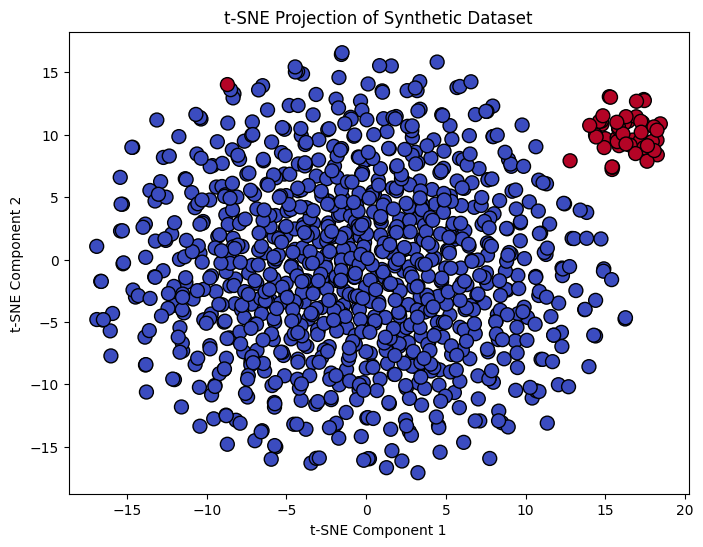

In [202]:
from sklearn.manifold import TSNE
tsne_projection = TSNE(n_components=2, random_state=42).fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(tsne_projection[:, 0], tsne_projection[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.title('t-SNE Projection of Synthetic Dataset')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()